단일 raw파일 확인하기  
Qt_rppg_b4.py 녹화

단일 .raw파일 frames폴더 만들어서 저장

In [1]:
# 파일명: raw_to_tiff_converter.py
# 지시사항:
# 1. 대상 폴더 경로 업데이트 (data\basler_0402\20260402_200457)
# 2. camera_all_settings.txt의 JSON 요약본을 파싱하여 해상도(Width, Height)와 포맷 추출
# 3. 픽셀 포맷(BayerRG12, BayerRG8, BGR8)에 따라 numpy 데이터 타입과 형태(Reshape) 자동 맞춤 적용

import os
import pandas as pd
import numpy as np
import tifffile
import sys
import json # 💡 JSON 파싱을 위해 추가

# =========================================================
# [설정] 변환할 폴더 경로
# =========================================================
TARGET_DIR = r"data\basler_0402\20260402_200457" # 💡 요청하신 경로로 수정됨
# =========================================================

def parse_camera_settings(txt_path):
    """camera_all_settings.txt 파일의 JSON 요약본에서 해상도와 포맷 정보를 추출합니다."""
    settings = {'Width': 1024, 'Height': 1024, 'PixelFormat': 'BayerRG12'} # 기본값
    
    if not os.path.exists(txt_path):
        print(f"⚠️ 설정 파일 없음: {txt_path} (기본값 사용)")
        return settings

    try:
        with open(txt_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        start_marker = "=== [Summary] Main Camera Settings ==="
        end_marker = "=== [Full Dump] Camera All Settings ==="
        
        start_idx = content.find(start_marker)
        end_idx = content.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            json_str = content[start_idx + len(start_marker):end_idx].strip()
            summary = json.loads(json_str)
            
            settings['Width'] = summary.get("Resolution", {}).get("Width", 1024)
            settings['Height'] = summary.get("Resolution", {}).get("Height", 1024)
            settings['PixelFormat'] = summary.get("PixelFormat", "BayerRG12")
            
            print(f"⚙️ 카메라 설정 확인: {settings['Width']}x{settings['Height']} | 포맷: {settings['PixelFormat']}")
            return settings
            
    except Exception as e:
        print(f"⚠️ JSON 파싱 에러 ({e}). 기본값을 사용합니다.")
        
    return settings

def convert_raw_to_tiff():
    print(f"🔍 변환 작업 시작: {TARGET_DIR}")
    
    raw_path = os.path.join(TARGET_DIR, "recording.raw")
    csv_path = os.path.join(TARGET_DIR, "camera_timestamps.csv")
    settings_path = os.path.join(TARGET_DIR, "camera_all_settings.txt")
    
    # 1. 파일 존재 여부 확인
    if not os.path.exists(raw_path):
        print(f"❌ RAW 파일을 찾을 수 없습니다: {raw_path}")
        return
    if not os.path.exists(csv_path):
        print(f"❌ CSV 파일을 찾을 수 없습니다: {csv_path}")
        return

    # 2. 해상도 및 포맷 파싱
    settings = parse_camera_settings(settings_path)
    IMG_W = settings['Width']
    IMG_H = settings['Height']
    PIXEL_FMT = settings['PixelFormat']

    # 💡 픽셀 포맷에 따른 numpy 파라미터 동적 결정 (하드코딩 제거)
    if "8" in PIXEL_FMT:  # 8비트 포맷 (BayerRG8, BGR8 등)
        np_dtype = np.uint8
        channels = 3 if "BGR" in PIXEL_FMT or "RGB" in PIXEL_FMT else 1
    else:                 # 12비트/16비트 포맷 (BayerRG12 등)
        np_dtype = np.uint16
        channels = 1
        
    pixels_per_frame = IMG_W * IMG_H * channels

    # 3. CSV를 통해 프레임 정보 확인
    df_cam = pd.read_csv(csv_path)
    expected_frames = len(df_cam)
    print(f"📄 CSV 기록 기준 프레임 수: {expected_frames}장")

    # 4. RAW 데이터 로드
    print(f"⏳ RAW 데이터를 메모리에 로드하는 중... (타입: {np_dtype.__name__})")
    raw_1d = np.fromfile(raw_path, dtype=np_dtype) 
    
    # 실제 파일 크기와 계산된 프레임 수가 맞는지 검증
    actual_frames = len(raw_1d) // pixels_per_frame
    
    if actual_frames < expected_frames:
        print(f"⚠️ 경고: RAW 파일이 온전히 저장되지 않았습니다. (실제 복구 가능: {actual_frames}장)")
    else:
        print(f"✅ RAW 데이터 무결성 확인 완료 ({actual_frames}장)")

    # 3차원 배열로 변환 (프레임 수, 높이, 너비, [채널])
    try:
        valid_data = raw_1d[:actual_frames * pixels_per_frame]
        if channels == 3:
            video_frames = valid_data.reshape((actual_frames, IMG_H, IMG_W, 3))
        else:
            video_frames = valid_data.reshape((actual_frames, IMG_H, IMG_W))
    except ValueError as e:
        print(f"❌ 데이터 Reshape 실패: {e}")
        return

    # 5. 프레임 저장 폴더 생성
    frames_dir = os.path.join(TARGET_DIR, "frames")
    if not os.path.exists(frames_dir):
        os.makedirs(frames_dir)
        print(f"📁 'frames' 폴더를 생성했습니다.")

    # 6. TIFF 낱장 추출 및 저장
    print("💾 TIFF 파일 추출을 시작합니다...")
    for i in range(actual_frames):
        # CSV에 기록된 원래 Frame_Index를 가져옵니다 (드랍된 인덱스 번호를 유지하기 위함)
        f_idx = int(df_cam['Frame_Index'].iloc[i]) if i < len(df_cam) else i
        
        file_name = f"frame_{f_idx:04d}.tiff"
        full_path = os.path.join(frames_dir, file_name)
        
        # tifffile을 사용해 무손실 저장
        tifffile.imwrite(full_path, video_frames[i])
        
        # 진행률 표시
        if i % 100 == 0 or i == actual_frames - 1:
            sys.stdout.write(f"\r➡️ 진행률: {i+1} / {actual_frames} 장 완료...")
            sys.stdout.flush()

    print(f"\n🎉 변환이 완료되었습니다! (저장 위치: {frames_dir})")

if __name__ == "__main__":
    convert_raw_to_tiff()

🔍 변환 작업 시작: data\basler_0402\20260402_200457
⚙️ 카메라 설정 확인: 1024x1024 | 포맷: BayerRG12
📄 CSV 기록 기준 프레임 수: 626장
⏳ RAW 데이터를 메모리에 로드하는 중... (타입: uint16)
✅ RAW 데이터 무결성 확인 완료 (626장)
📁 'frames' 폴더를 생성했습니다.
💾 TIFF 파일 추출을 시작합니다...
➡️ 진행률: 626 / 626 장 완료...
🎉 변환이 완료되었습니다! (저장 위치: data\basler_0402\20260402_200457\frames)


변화코드 
-메모리에 한번에 올리지말고 한장씩

In [ ]:
# 파일명: raw_to_tiff_converter_memory_safe.py
# 지시사항:
# 1. 대상 폴더 경로 업데이트 (data\basler_0402\20260402_200457)
# 2. camera_all_settings.txt의 JSON 요약본을 파싱하여 해상도(Width, Height)와 포맷 추출
# 3. 픽셀 포맷에 따라 프레임당 바이트(Bytes) 크기를 동적 계산하여 메모리 오버플로우 없이 1프레임씩 안전 변환

import os
import pandas as pd
import numpy as np
import tifffile
import sys
import json # 💡 JSON 파싱을 위해 추가

# =========================================================
# [설정] 변환할 폴더 경로
# =========================================================
TARGET_DIR = r"data\basler_0402\20260402_200457" # 💡 요청하신 경로로 변경
# =========================================================

def parse_camera_settings(txt_path):
    """camera_all_settings.txt 파일의 JSON 요약본에서 해상도와 포맷 정보를 추출합니다."""
    settings = {'Width': 1024, 'Height': 1024, 'PixelFormat': 'BayerRG12'} # 기본값
    
    if not os.path.exists(txt_path):
        print(f"⚠️ 설정 파일 없음: {txt_path} (기본값 사용)")
        return settings

    try:
        with open(txt_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        start_marker = "=== [Summary] Main Camera Settings ==="
        end_marker = "=== [Full Dump] Camera All Settings ==="
        
        start_idx = content.find(start_marker)
        end_idx = content.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            json_str = content[start_idx + len(start_marker):end_idx].strip()
            summary = json.loads(json_str)
            
            settings['Width'] = summary.get("Resolution", {}).get("Width", 1024)
            settings['Height'] = summary.get("Resolution", {}).get("Height", 1024)
            settings['PixelFormat'] = summary.get("PixelFormat", "BayerRG12")
            
            print(f"⚙️ 카메라 설정 확인: {settings['Width']}x{settings['Height']} | 포맷: {settings['PixelFormat']}")
            return settings
            
    except Exception as e:
        print(f"⚠️ JSON 파싱 에러 ({e}). 기본값을 사용합니다.")
        
    return settings

def convert_raw_to_tiff_safe():
    print(f"🔍 변환 작업 시작 (메모리 절약 모드): {TARGET_DIR}")
    
    raw_path = os.path.join(TARGET_DIR, "recording.raw")
    csv_path = os.path.join(TARGET_DIR, "camera_timestamps.csv")
    settings_path = os.path.join(TARGET_DIR, "camera_all_settings.txt")
    
    if not os.path.exists(raw_path) or not os.path.exists(csv_path):
        print("❌ RAW 또는 CSV 파일을 찾을 수 없습니다.")
        return

    # 1. 해상도 및 프레임 크기 파싱
    settings = parse_camera_settings(settings_path)
    IMG_W = settings['Width']
    IMG_H = settings['Height']
    PIXEL_FMT = settings['PixelFormat']
    
    # 💡 2. 픽셀 포맷에 따른 데이터 타입, 채널 및 바이트 크기 동적 계산 (하드코딩 제거)
    if "8" in PIXEL_FMT:  # 8비트 포맷 (BayerRG8, BGR8 등)
        np_dtype = np.uint8
        bytes_per_pixel = 1
        channels = 3 if "BGR" in PIXEL_FMT or "RGB" in PIXEL_FMT else 1
    else:                 # 12비트/16비트 포맷 (BayerRG12 등)
        np_dtype = np.uint16
        bytes_per_pixel = 2
        channels = 1
        
    # 정확한 1프레임당 용량(Bytes) 계산
    bytes_per_frame = IMG_W * IMG_H * channels * bytes_per_pixel
    
    # 3. CSV 프레임 수 확인
    df_cam = pd.read_csv(csv_path)
    expected_frames = len(df_cam)
    
    # 4. 실제 RAW 파일 용량으로 복구 가능한 프레임 수 계산
    file_size = os.path.getsize(raw_path)
    actual_frames = file_size // bytes_per_frame
    
    print(f"📄 CSV 프레임: {expected_frames}장 / 📦 실제 복구 가능 프레임: {actual_frames}장")
    print(f"   - 프레임당 용량: {bytes_per_frame} Bytes (타입: {np_dtype.__name__})")

    frames_dir = os.path.join(TARGET_DIR, "frames")
    if not os.path.exists(frames_dir):
        os.makedirs(frames_dir)

    print("💾 TIFF 파일 추출을 시작합니다... (RAM 최소화)")
    
    # =========================================================
    # 💡 [핵심] 파일을 통째로 읽지 않고, 스트림으로 열어서 1프레임씩만 읽습니다.
    # =========================================================
    with open(raw_path, 'rb') as f:
        for i in range(actual_frames):
            # 딱 1프레임 용량만 디스크에서 읽어옵니다.
            raw_bytes = f.read(bytes_per_frame)
            
            # 파일 끝에 도달했거나 바이트가 모자란 경우 종료
            if not raw_bytes or len(raw_bytes) < bytes_per_frame:
                break 
            
            # 읽어온 바이트를 Numpy 배열로 변환 후 Reshape
            if channels == 3:
                frame_arr = np.frombuffer(raw_bytes, dtype=np_dtype).reshape((IMG_H, IMG_W, 3))
            else:
                frame_arr = np.frombuffer(raw_bytes, dtype=np_dtype).reshape((IMG_H, IMG_W))
            
            # CSV 인덱스 매칭
            f_idx = int(df_cam['Frame_Index'].iloc[i]) if i < len(df_cam) else i
            file_name = f"frame_{f_idx:04d}.tiff"
            full_path = os.path.join(frames_dir, file_name)
            
            # 낱장 저장
            tifffile.imwrite(full_path, frame_arr)
            
            # 진행률 업데이트
            if i % 100 == 0 or i == actual_frames - 1:
                sys.stdout.write(f"\r➡️ 진행률: {i+1} / {actual_frames} 장 완료...")
                sys.stdout.flush()

    print(f"\n🎉 변환이 완벽하게 완료되었습니다! (저장 위치: {frames_dir})")

if __name__ == "__main__":
    convert_raw_to_tiff_safe()

🔍 변환 작업 시작 (메모리 절약 모드): data\basler_raw_rec\20260226_161057
⚙️ 카메라 해상도 확인: 1024 x 1024
📄 CSV 프레임: 1202장 / 📦 실제 복구 가능 프레임: 1202장
💾 TIFF 파일 추출을 시작합니다... (RAM 최소화)
➡️ 진행률: 1202 / 1202 장 완료...
🎉 변환이 완벽하게 완료되었습니다! (저장 위치: data\basler_raw_rec\20260226_161057\frames)


프레임 + 데이터 검증

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import json # JSON 파싱을 위해 추가

# =========================================================
# [설정] 검증할 폴더 경로 (여기를 수정하세요)
# =========================================================

TARGET_DIR = r"data\basler_0402\20260402_200457"

TARGET_SENSOR_HZ = 200  # 센서 하드웨어 전송 속도는 고정 (200Hz)
# =========================================================

def load_settings_from_txt(target_dir):
    """
    camera_all_settings.txt 파일 상단의 JSON 요약본을 파싱하여 
    실제 녹화 시간과 목표 FPS를 반환합니다.
    """
    settings_path = os.path.join(target_dir, "camera_all_settings.txt")
    default_duration = 60.0
    default_fps = 60.0
    
    if not os.path.exists(settings_path):
        print(f"⚠️ 'camera_all_settings.txt'가 없습니다. 기본값(60초, 60fps)으로 검증합니다.")
        return default_duration, default_fps

    try:
        with open(settings_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        # 텍스트 내에서 JSON 요약 블록만 추출
        start_marker = "=== [Summary] Main Camera Settings ==="
        end_marker = "=== [Full Dump] Camera All Settings ==="
        
        start_idx = content.find(start_marker)
        end_idx = content.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            json_str = content[start_idx + len(start_marker):end_idx].strip()
            summary = json.loads(json_str)
            
            duration = summary.get("Record_Duration_sec", default_duration)
            # Result(실제 FPS)를 우선으로 하되 없으면 Target(설정 FPS) 사용
            fps = summary.get("FPS_Result", summary.get("FPS_Target", default_fps))
            version = summary.get("Program_Version", "Unknown")
            
            print(f"📄 [설정 파일 로드 성공]")
            print(f"   - 수집 환경: {version}")
            print(f"   - 녹화 시간: {duration} 초")
            print(f"   - 설정 FPS : {fps} fps")
            return float(duration), float(fps)
            
    except Exception as e:
        print(f"⚠️ 설정 파일 파싱 실패 ({e}). 기본값으로 진행합니다.")
        
    return default_duration, default_fps

def verify_recording():
    print(f"🔍 데이터 검증 시작: {TARGET_DIR}\n")
    
    if not os.path.exists(TARGET_DIR):
        print(f"❌ 폴더를 찾을 수 없습니다: {TARGET_DIR}")
        return

    # 💡 1. 텍스트 파일에서 동적 파라미터 로드
    actual_duration, target_fps = load_settings_from_txt(TARGET_DIR)
    
    # 목표 데이터 개수 동적 계산
    expected_cam_frames = int(actual_duration * target_fps)
    expected_sensor_data = int(actual_duration * TARGET_SENSOR_HZ)
    print("-" * 40)

    # -----------------------------------------------------
    # 2. 이미지 파일(.tiff) 개수 확인
    # -----------------------------------------------------
    frames_dir = os.path.join(TARGET_DIR, "frames")
    if not os.path.exists(frames_dir):
        print("❌ 'frames' 폴더가 없습니다! (혹시 .raw 저장 버전인가요?)")
        tiff_count = 0
    else:
        tiff_files = glob.glob(os.path.join(frames_dir, "*.tiff"))
        tiff_count = len(tiff_files)
    
    print(f"📸 [이미지 파일 검사]")
    print(f"   - 파일 개수: {tiff_count} 장")
    # 오차 범위는 초당 1~2프레임 내외로 허용 (예: 총 프레임의 약 2% 내외)
    margin_cam = max(10, int(expected_cam_frames * 0.03)) 
    if abs(tiff_count - expected_cam_frames) <= margin_cam:
        print(f"   - ✅ 판정: {target_fps}fps 카메라 저장 양호 (목표: {expected_cam_frames}장)")
    else:
        print(f"   - ⚠️ 판정: 카메라 프레임 수 부족/초과 (목표: {expected_cam_frames}장)")
    print("-" * 40)

    # -----------------------------------------------------
    # 3. 카메라 타임스탬프 (camera_timestamps.csv) 분석
    # -----------------------------------------------------
    cam_csv_path = os.path.join(TARGET_DIR, "camera_timestamps.csv")
    if os.path.exists(cam_csv_path):
        df_cam = pd.read_csv(cam_csv_path)
        
        cam_start = df_cam['Timestamp'].iloc[0]
        cam_end = df_cam['Timestamp'].iloc[-1]
        cam_duration = cam_end - cam_start
        cam_actual_fps = len(df_cam) / cam_duration if cam_duration > 0 else 0
        
        print(f"🎥 [카메라 로그 분석]")
        print(f"   - 기록된 프레임 수 : {len(df_cam)} 개")
        print(f"   - 로그상 녹화 시간 : {cam_duration:.2f} 초")
        print(f"   - 계산된 평균 FPS  : {cam_actual_fps:.2f} fps")
        
        if tiff_count == len(df_cam) or tiff_count == 0: # raw 버전을 위해 0장일때 조건 추가
            print("   - ✅ 파일 수 == 로그 수 일치 (또는 단일 .raw 포맷)")
        else:
            print(f"   - ❌ 불일치! (이미지: {tiff_count}장 vs 로그: {len(df_cam)}줄)")
    else:
        print("❌ 'camera_timestamps.csv' 파일 없음")
    print("-" * 40)

    # -----------------------------------------------------
    # 4. 센서 데이터 (ppg_sensor.csv) 분석 
    # -----------------------------------------------------
    sensor_csv_path = os.path.join(TARGET_DIR, "ppg_sensor.csv")
    if os.path.exists(sensor_csv_path):
        df_sensor = pd.read_csv(sensor_csv_path)
        
        sen_start = df_sensor['Timestamp'].iloc[0]
        sen_end = df_sensor['Timestamp'].iloc[-1]
        sen_duration = sen_end - sen_start
        sen_hz = len(df_sensor) / sen_duration if sen_duration > 0 else 0
        
        print(f"📡 [센서 데이터 분석]")
        print(f"   - 데이터 개수    : {len(df_sensor)} 개")
        print(f"   - 로그상 녹화 시간 : {sen_duration:.2f} 초")
        print(f"   - 평균 샘플링    : {sen_hz:.2f} Hz (목표: {TARGET_SENSOR_HZ}Hz)")
        
        margin_sensor = max(50, int(expected_sensor_data * 0.04)) # 약 4% 오차 허용
        if abs(len(df_sensor) - expected_sensor_data) <= margin_sensor:
            print(f"   - ✅ 데이터 양 양호 (목표 {expected_sensor_data}개 기준)")
        else:
            print(f"   - ⚠️ 데이터 양 이상 (목표: {expected_sensor_data}, 실제: {len(df_sensor)})")

        if 'Frame_Index' in df_sensor.columns:
            seqs = df_sensor['Frame_Index'].values
            diffs = (np.diff(seqs) - 1) % 256 
            total_drops = np.sum(diffs)
            
            if total_drops == 0:
                print("   - 🏆 [Perfect] 패킷 드랍 0개! (센서 무결성 검증 완료)")
            else:
                print(f"   - 🩸 [Warning] 총 {total_drops} 개의 패킷이 유실되었습니다.")
        else:
            print("   - (Frame_Index 컬럼이 없어 정밀 드랍 체크 건너뜀)")

    else:
        print("❌ 'ppg_sensor.csv' 파일 없음")
    
    print("\n✨ 검증 완료")

if __name__ == "__main__":
    verify_recording()

🔍 데이터 검증 시작: data\basler_0402\20260402_200457

📄 [설정 파일 로드 성공]
   - 수집 환경: SingleRaw
   - 녹화 시간: 10.44 초
   - 설정 FPS : 60.0 fps
----------------------------------------
📸 [이미지 파일 검사]
   - 파일 개수: 626 장
   - ✅ 판정: 60.0fps 카메라 저장 양호 (목표: 626장)
----------------------------------------
🎥 [카메라 로그 분석]
   - 기록된 프레임 수 : 626 개
   - 로그상 녹화 시간 : 10.42 초
   - 계산된 평균 FPS  : 60.07 fps
   - ✅ 파일 수 == 로그 수 일치 (또는 단일 .raw 포맷)
----------------------------------------
📡 [센서 데이터 분석]
   - 데이터 개수    : 2081 개
   - 로그상 녹화 시간 : 10.42 초
   - 평균 샘플링    : 199.69 Hz (목표: 200Hz)
   - ✅ 데이터 양 양호 (목표 2088개 기준)
   - 🏆 [Perfect] 패킷 드랍 0개! (센서 무결성 검증 완료)

✨ 검증 완료


영상 + PPG데이터 동시에 확인

In [4]:
import cv2
import pandas as pd
import numpy as np
import tifffile
import os
import json # 💡 JSON 파싱을 위해 추가

# =========================================================
# [설정] 재생할 폴더 및 옵션
# =========================================================
TARGET_DIR = r"data\basler_0402\20260402_200457"

START_SEC = 10       # 시작 시간 (초)
DURATION_SEC = 5    # 재생 길이 (초) (None 또는 0으로 설정 시 끝까지 재생)
VIEW_SCALE = 0.6     # 화면 크기 비율 (0.5 = 50%)
# =========================================================

def load_settings_from_txt(target_dir):
    """
    camera_all_settings.txt 파일 상단의 JSON 요약본을 파싱하여 
    실제 녹화 시간, 설정 FPS, 픽셀 포맷을 반환합니다.
    """
    settings_path = os.path.join(target_dir, "camera_all_settings.txt")
    default_duration = 60.0
    default_fps = 60.0
    default_format = "BayerRG12"
    
    if not os.path.exists(settings_path):
        print(f"⚠️ 'camera_all_settings.txt'가 없습니다. 기본값으로 재생합니다.")
        return default_duration, default_fps, default_format

    try:
        with open(settings_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        start_marker = "=== [Summary] Main Camera Settings ==="
        end_marker = "=== [Full Dump] Camera All Settings ==="
        
        start_idx = content.find(start_marker)
        end_idx = content.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            json_str = content[start_idx + len(start_marker):end_idx].strip()
            summary = json.loads(json_str)
            
            duration = summary.get("Record_Duration_sec", default_duration)
            fps = summary.get("FPS_Result", summary.get("FPS_Target", default_fps))
            pixel_format = summary.get("PixelFormat", default_format)
            
            print(f"📄 [설정 파일 로드 성공]")
            print(f"   - 총 녹화 시간: {duration} 초")
            print(f"   - 녹화 FPS    : {fps} fps")
            print(f"   - 픽셀 포맷   : {pixel_format}")
            return float(duration), float(fps), pixel_format
            
    except Exception as e:
        print(f"⚠️ 설정 파일 파싱 실패 ({e}). 기본값으로 진행합니다.")
        
    return default_duration, default_fps, default_format


def play_synced_data():
    if not os.path.exists(TARGET_DIR):
        print("❌ 폴더를 찾을 수 없습니다.")
        return

    print("📂 데이터 로딩 및 동기화 준비 중...")

    # 💡 1. 텍스트 파일에서 동적 파라미터 로드 (하드코딩 제거)
    total_duration, play_fps, pixel_format = load_settings_from_txt(TARGET_DIR)

    # 2. CSV 로드
    cam_csv = os.path.join(TARGET_DIR, "camera_timestamps.csv")
    sen_csv = os.path.join(TARGET_DIR, "ppg_sensor.csv")
    
    if not os.path.exists(cam_csv) or not os.path.exists(sen_csv):
        print("❌ CSV 파일이 없습니다.")
        return

    df_cam = pd.read_csv(cam_csv)
    df_sen = pd.read_csv(sen_csv)

    # 3. 시간 동기화
    base_time = df_cam['Timestamp'].iloc[0]
    df_cam['Rel_Time'] = df_cam['Timestamp'] - base_time
    df_sen['Rel_Time'] = df_sen['Timestamp'] - base_time

    # 4. 구간 자르기 (DURATION_SEC이 없으면 전체 재생)
    end_sec = START_SEC + DURATION_SEC if DURATION_SEC else total_duration
    
    mask_cam = (df_cam['Rel_Time'] >= START_SEC) & (df_cam['Rel_Time'] <= end_sec)
    df_cam_cut = df_cam[mask_cam].reset_index(drop=True)
    
    mask_sen = (df_sen['Rel_Time'] >= START_SEC) & (df_sen['Rel_Time'] <= end_sec)
    df_sen_cut = df_sen[mask_sen].reset_index(drop=True)

    if len(df_cam_cut) == 0:
        print("⚠️ 해당 구간에 데이터가 없습니다.")
        return
    
    frames_dir = os.path.join(TARGET_DIR, "frames")

    # 이미지 크기 자동 감지 (그래프 width 맞추기 위해)
    first_fname = f"frame_{int(df_cam_cut.iloc[0]['Frame_Index']):04d}.tiff"
    first_path = os.path.join(frames_dir, first_fname)
    if os.path.exists(first_path):
        tmp_img = tifffile.imread(first_path)
        IMG_H, IMG_W = tmp_img.shape[:2]
    else:
        IMG_W = 1024 # 파일 없으면 기본값

    print(f"🎬 재생 시작: {START_SEC}~{end_sec}초 (원본: {IMG_W}x{IMG_H} -> 축소: {int(VIEW_SCALE*100)}%)")
    print("   [Space]: 일시정지 / [ESC]: 종료")

    # 5. 그래프 배경 그리기
    W_IMG = IMG_W  
    H_GRAPH = 200 
    graph_bg = np.zeros((H_GRAPH, W_IMG, 3), dtype=np.uint8) 

    if len(df_sen_cut) > 1:
        t_vals = df_sen_cut['Rel_Time'].values
        
        # 컬럼 이름 호환성 체크 (Raw vs Processed)
        col_name = 'IR_Value_Raw' if 'IR_Value_Raw' in df_sen_cut.columns else 'IR_Value'
        y_vals = df_sen_cut[col_name].values
        
        # X축/Y축 스케일링
        x_norm = (t_vals - START_SEC) / (end_sec - START_SEC) * W_IMG
        
        y_min, y_max = y_vals.min(), y_vals.max()
        if y_max == y_min: y_max += 1 
        
        y_norm = H_GRAPH - ((y_vals - y_min) / (y_max - y_min) * (H_GRAPH - 20)) - 10

        pts = np.column_stack((x_norm, y_norm)).astype(np.int32)
        cv2.polylines(graph_bg, [pts], isClosed=False, color=(0, 255, 0), thickness=2)

    # 6. 재생 루프
    wait_ms = int(1000 / play_fps) if play_fps > 0 else 16 # 💡 동적 재생 속도 적용

    for i, row in df_cam_cut.iterrows():
        # --- 영상 로드 ---
        fname = f"frame_{int(row['Frame_Index']):04d}.tiff"
        path = os.path.join(frames_dir, fname)
        
        if not os.path.exists(path):
            continue

        raw_img = tifffile.imread(path)
        
        # 💡 [수정] 픽셀 포맷에 따른 동적 이미지 변환 로직 적용
        if pixel_format == "BGR8":
            view_img = raw_img  # 이미 8-bit BGR 이므로 그대로 사용
        elif pixel_format == "BayerRG8":
            view_img = cv2.cvtColor(raw_img, cv2.COLOR_BayerBG2BGR)
        else: # 기본 BayerRG12
            rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BayerBG2BGR)
            view_img = (rgb_img >> 4).astype(np.uint8) # 12bit -> 8bit 변환

        # --- 그래프 업데이트 ---
        graph_curr = graph_bg.copy()
        curr_t = row['Rel_Time']
        
        # 커서 위치 계산 (비율에 맞춰 정확히)
        cursor_x = int((curr_t - START_SEC) / (end_sec - START_SEC) * W_IMG)
        
        # 커서 그리기
        cv2.line(graph_curr, (cursor_x, 0), (cursor_x, H_GRAPH), (0, 0, 255), 2)
        cv2.putText(graph_curr, f"T: {curr_t:.3f}s", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        # --- 합치기 ---
        try:
            final_view = cv2.vconcat([view_img, graph_curr])
        except:
            print("⚠️ 이미지와 그래프 크기가 맞지 않아 합칠 수 없습니다.")
            final_view = view_img

        # --- 리사이즈 (보기 편하게) ---
        h, w = final_view.shape[:2]
        new_w = int(w * VIEW_SCALE)
        new_h = int(h * VIEW_SCALE)
        final_view = cv2.resize(final_view, (new_w, new_h), interpolation=cv2.INTER_AREA)

        cv2.imshow("Sync Player", final_view)

        key = cv2.waitKey(wait_ms)
        if key == 27: # ESC
            break
        elif key == 32: # Space
            cv2.waitKey()

    cv2.destroyAllWindows()
    print("✨ 종료되었습니다.")

if __name__ == "__main__":
    play_synced_data()

📂 데이터 로딩 및 동기화 준비 중...
📄 [설정 파일 로드 성공]
   - 총 녹화 시간: 10.44 초
   - 녹화 FPS    : 60.0 fps
   - 픽셀 포맷   : BayerRG12
🎬 재생 시작: 10~15초 (원본: 1024x1024 -> 축소: 60%)
   [Space]: 일시정지 / [ESC]: 종료
✨ 종료되었습니다.


지정영역 내 G채널 평균, PPG데이터 같이 출력

📄 [설정 파일 로드] 픽셀 포맷: BayerRG12
📂 데이터 및 타임스탬프 로드 중...

🎥 [1/2] ROI 설정을 위해 첫 번째 프레임을 불러옵니다...
✅ 선택된 ROI: x=466, y=44, w=76, h=71
⏳ 300개 프레임에서 G채널 값을 추출 중입니다...
📡 [2/2] 센서 데이터를 처리합니다...
⚡ 실제 샘플링: 센서 200.0Hz / 카메라 60.0Hz
❤️ 센서 BPM: 83.1 | 📷 카메라 G채널 BPM: 88.3


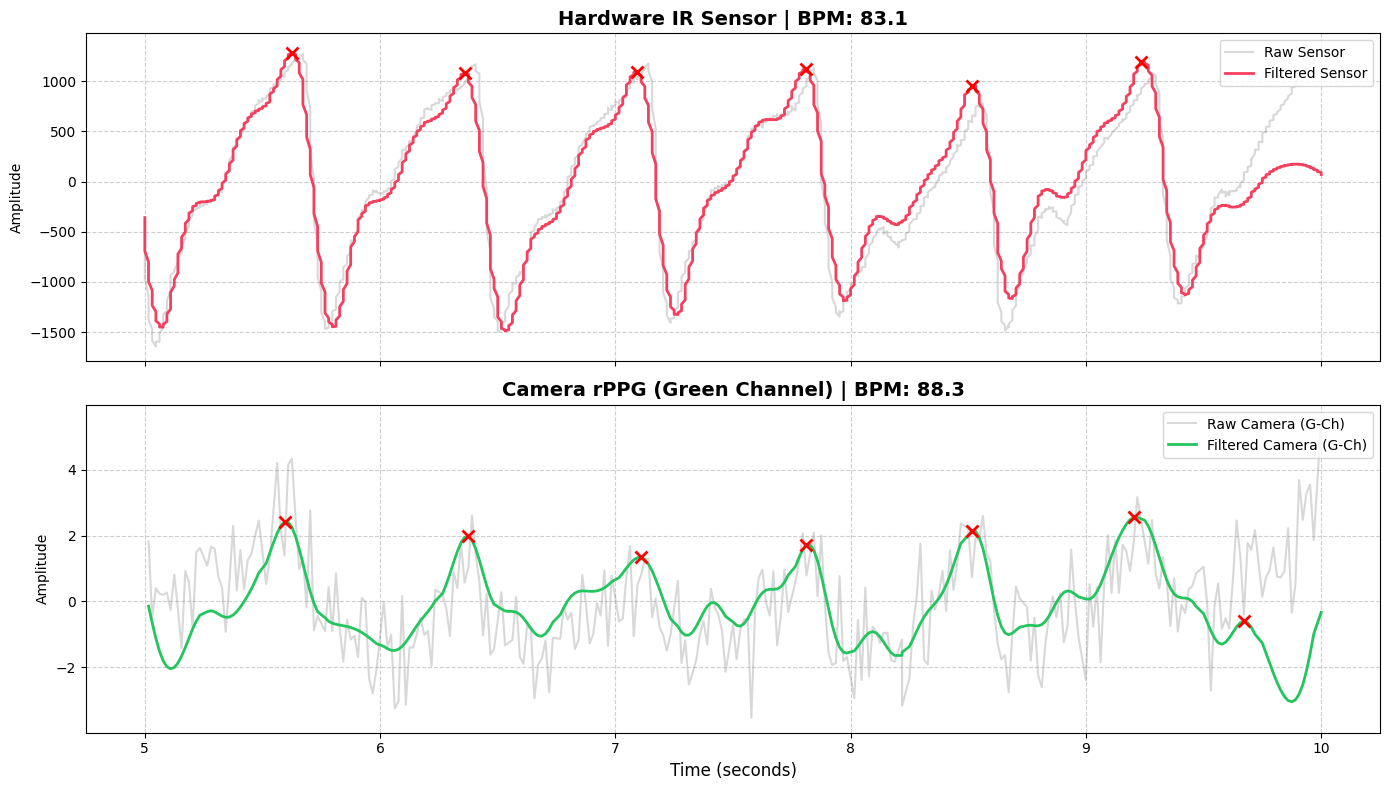

In [5]:
import os
import cv2
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
import json # 💡 JSON 파싱을 위해 추가

# =========================================================
# [설정] 분석할 폴더 및 옵션
# =========================================================
TARGET_DIR = r"data\basler_0402\20260402_200457"

START_SEC = 5       # 분석 시작 시간 (초)
DURATION_SEC = 5     # 분석할 길이 (초)

# 대상 설정 ('human' 또는 'mouse')
TARGET_TYPE = 'human' 
# TARGET_TYPE = 'mouse' 

# 그래프 설정
INVERT_SENSOR = False  # 센서 신호 뒤집기
INVERT_CAMERA = False  # 카메라 G채널 뒤집기 (일반적으로 rPPG는 -G를 써야 혈류량과 비례함)
SHOW_FILTERED = True   # 필터링된 신호로 계산할지 여부
# =========================================================

# 💡 [신규] 설정 파일에서 픽셀 포맷 읽어오기
def load_pixel_format_from_txt(target_dir):
    settings_path = os.path.join(target_dir, "camera_all_settings.txt")
    default_format = "BayerRG12"
    
    if not os.path.exists(settings_path):
        print(f"⚠️ 'camera_all_settings.txt'가 없습니다. 기본값({default_format})으로 진행합니다.")
        return default_format

    try:
        with open(settings_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        start_marker = "=== [Summary] Main Camera Settings ==="
        end_marker = "=== [Full Dump] Camera All Settings ==="
        
        start_idx = content.find(start_marker)
        end_idx = content.find(end_marker)
        
        if start_idx != -1 and end_idx != -1:
            json_str = content[start_idx + len(start_marker):end_idx].strip()
            summary = json.loads(json_str)
            pixel_format = summary.get("PixelFormat", default_format)
            
            print(f"📄 [설정 파일 로드] 픽셀 포맷: {pixel_format}")
            return pixel_format
            
    except Exception as e:
        print(f"⚠️ 설정 파싱 실패 ({e}). 기본값으로 진행합니다.")
        
    return default_format


def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def analyze_ppg():
    sensor_csv = os.path.join(TARGET_DIR, "ppg_sensor.csv")
    camera_csv = os.path.join(TARGET_DIR, "camera_timestamps.csv")
    frames_dir = os.path.join(TARGET_DIR, "frames")
    
    if not os.path.exists(sensor_csv) or not os.path.exists(camera_csv):
        print("❌ CSV 파일을 찾을 수 없습니다. 경로를 확인하세요.")
        return

    # 💡 텍스트 파일에서 동적 파라미터 로드
    pixel_format = load_pixel_format_from_txt(TARGET_DIR)

    print("📂 데이터 및 타임스탬프 로드 중...")
    df_sensor = pd.read_csv(sensor_csv)
    df_cam = pd.read_csv(camera_csv)

    # 1. 공통 시간축(t0) 설정 (두 기기 중 가장 먼저 시작된 시간을 0초로 기준)
    t0 = min(df_sensor['Timestamp'].iloc[0], df_cam['Timestamp'].iloc[0])

    # 2. 지정된 시간 구간 마스크 생성
    end_sec = START_SEC + DURATION_SEC
    
    sensor_mask = (df_sensor['Timestamp'] - t0 >= START_SEC) & (df_sensor['Timestamp'] - t0 <= end_sec)
    cam_mask = (df_cam['Timestamp'] - t0 >= START_SEC) & (df_cam['Timestamp'] - t0 <= end_sec)

    df_sensor_cut = df_sensor[sensor_mask]
    df_cam_cut = df_cam[cam_mask]

    if len(df_sensor_cut) == 0 or len(df_cam_cut) == 0:
        print("⚠️ 해당 구간에 데이터가 부족합니다.")
        return

    # =========================================================
    # [1단계] 카메라 영상 ROI 설정 및 G채널 추출 
    # =========================================================
    print(f"\n🎥 [1/2] ROI 설정을 위해 첫 번째 프레임을 불러옵니다...")
    first_frame_idx = int(df_cam_cut['Frame_Index'].iloc[0])
    first_frame_path = os.path.join(frames_dir, f"frame_{first_frame_idx:04d}.tiff")
    
    raw_img = tifffile.imread(first_frame_path)
    
    # 💡 [수정] 픽셀 포맷에 따른 동적 이미지 변환 (ROI 선택용 8비트 화면 생성)
    if pixel_format == "BGR8":
        view_img = raw_img
    elif pixel_format == "BayerRG8":
        view_img = cv2.cvtColor(raw_img, cv2.COLOR_BayerBG2BGR)
    else: # BayerRG12 (기본값)
        rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BayerBG2BGR)
        view_img = (rgb_img >> 4).astype(np.uint8)

    # ROI 창 띄우기
    cv2.namedWindow("Select ROI (Drag & Press SPACE)", cv2.WINDOW_NORMAL)
    roi = cv2.selectROI("Select ROI (Drag & Press SPACE)", view_img, fromCenter=False, showCrosshair=True)
    cv2.destroyAllWindows()

    x, y, w, h = [int(v) for v in roi]
    
    if w == 0 or h == 0:
        print("⚠️ ROI가 선택되지 않았습니다. 종료합니다.")
        return
        
    # Bayer 패턴이 깨지지 않도록 x, y를 짝수 인덱스로 강제 보정
    x, y = x & ~1, y & ~1 
    print(f"✅ 선택된 ROI: x={x}, y={y}, w={w}, h={h}")

    # 영상 프레임 순회하며 G채널 평균 추출
    print(f"⏳ {len(df_cam_cut)}개 프레임에서 G채널 값을 추출 중입니다...")
    g_values = []
    t_cam = []
    
    for idx, row in df_cam_cut.iterrows():
        f_idx = int(row['Frame_Index'])
        f_time = row['Timestamp'] - t0
        
        f_path = os.path.join(frames_dir, f"frame_{f_idx:04d}.tiff")
        img = tifffile.imread(f_path)
        
        # [속도 최적화] 전체 변환 안 하고, 딱 ROI 영역만 자르기
        crop_img = img[y:y+h, x:x+w]
        
        # 💡 [수정] 픽셀 포맷에 따른 컬러 변환 적용
        if pixel_format == "BGR8":
            bgr_crop = crop_img
        else: # BayerRG8 또는 BayerRG12
            bgr_crop = cv2.cvtColor(crop_img, cv2.COLOR_BayerBG2BGR)
        
        # G채널(인덱스 1)의 공간 평균 계산 (16비트 데이터 그대로 평균내어 정밀도 유지)
        g_mean = np.mean(bgr_crop[:, :, 1])
        g_values.append(g_mean)
        t_cam.append(f_time)

    t_cam = np.array(t_cam)
    y_cam = np.array(g_values)

    # =========================================================
    # [2단계] 센서 데이터 추출
    # =========================================================
    print(f"📡 [2/2] 센서 데이터를 처리합니다...")
    t_sensor = df_sensor_cut['Timestamp'].values - t0
    y_sensor = df_sensor_cut['IR_Value_Raw'].values if 'IR_Value_Raw' in df_sensor_cut.columns else df_sensor_cut['IR_Value'].values

    # =========================================================
    # [3단계] 신호 필터링 및 피크 검출
    # =========================================================
    fs_cam = 1.0 / np.mean(np.diff(t_cam))
    fs_sensor = 1.0 / np.mean(np.diff(t_sensor))
    
    print(f"⚡ 실제 샘플링: 센서 {fs_sensor:.1f}Hz / 카메라 {fs_cam:.1f}Hz")

    if TARGET_TYPE == 'mouse':
        low_cut, high_cut, min_dist = 2.0, 15.0, 0.05
    else:
        low_cut, high_cut, min_dist = 0.5, 5.0, 0.35

    if INVERT_SENSOR: y_sensor = -y_sensor
    if INVERT_CAMERA: y_cam = -y_cam

    y_sensor_filt = butter_bandpass_filter(y_sensor, low_cut, high_cut, fs_sensor)
    y_cam_filt = butter_bandpass_filter(y_cam, low_cut, high_cut, fs_cam)

    y_sensor_target = y_sensor_filt if SHOW_FILTERED else y_sensor
    y_cam_target = y_cam_filt if SHOW_FILTERED else y_cam

    peaks_sen, _ = find_peaks(y_sensor_target, distance=int(min_dist * fs_sensor), prominence=np.std(y_sensor_target)*0.5)
    peaks_cam, _ = find_peaks(y_cam_target, distance=int(min_dist * fs_cam), prominence=np.std(y_cam_target)*0.5)

    bpm_sen = 60.0 / np.mean(np.diff(t_sensor[peaks_sen])) if len(peaks_sen) > 1 else 0
    bpm_cam = 60.0 / np.mean(np.diff(t_cam[peaks_cam])) if len(peaks_cam) > 1 else 0

    print(f"❤️ 센서 BPM: {bpm_sen:.1f} | 📷 카메라 G채널 BPM: {bpm_cam:.1f}")

    # =========================================================
    # [시각화] Matplotlib 그래프 그리기
    # =========================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # --- [상단] 센서 신호 ---
    ax1.plot(t_sensor, y_sensor - np.mean(y_sensor), color='gray', alpha=0.3, label='Raw Sensor')
    ax1.plot(t_sensor, y_sensor_target, color='#f43f5e', linewidth=2, label='Filtered Sensor')
    if len(peaks_sen) > 0:
        ax1.plot(t_sensor[peaks_sen], y_sensor_target[peaks_sen], "x", color='red', markersize=8, markeredgewidth=2)
    ax1.set_title(f"Hardware IR Sensor | BPM: {bpm_sen:.1f}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Amplitude")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- [하단] 카메라 G채널 신호 ---
    ax2.plot(t_cam, y_cam - np.mean(y_cam), color='gray', alpha=0.3, label='Raw Camera (G-Ch)')
    ax2.plot(t_cam, y_cam_target, color='#22c55e', linewidth=2, label='Filtered Camera (G-Ch)')
    if len(peaks_cam) > 0:
        ax2.plot(t_cam[peaks_cam], y_cam_target[peaks_cam], "x", color='red', markersize=8, markeredgewidth=2)
    ax2.set_title(f"Camera rPPG (Green Channel) | BPM: {bpm_cam:.1f}", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Time (seconds)", fontsize=12)
    ax2.set_ylabel("Amplitude")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_ppg()